# Import Library

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 0) Cấu hình đường dẫn

In [71]:
IMAGE_PATH = "Image/image.jpg"         
OUT_DIR = Path("output") 
OUT_DIR.mkdir(exist_ok=True)

# 1) Load ảnh + chuyển xám

In [72]:
img_bgr = cv2.imread(IMAGE_PATH)
if img_bgr is None:
    raise FileNotFoundError(
        f"Không đọc được ảnh '{IMAGE_PATH}'. "
        "Hãy kiểm tra đường dẫn hoặc tên file."
    )

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

gray_smooth = cv2.GaussianBlur(gray, (3, 3), 0)

blur = cv2.GaussianBlur(img_rgb, (3,3), 0)


# 2) Sobel (biên theo x, y + magnitude)

In [73]:
sobelx = cv2.Sobel(gray_smooth, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray_smooth, cv2.CV_64F, 0, 1, ksize=3)

# Độ lớn gradient: sqrt(sobelx^2 + sobely^2)
sobel_mag = cv2.magnitude(sobelx, sobely)

# Chuẩn hoá về uint8 để hiển thị/lưu ảnh
sobelx_u8 = cv2.convertScaleAbs(sobelx)
sobely_u8 = cv2.convertScaleAbs(sobely)
sobel_mag_u8 = cv2.convertScaleAbs(sobel_mag)

def sobel_mag1(x, k=3):
    sx = cv2.Sobel(x, cv2.CV_64F, 1, 0, ksize=k)
    sy = cv2.Sobel(x, cv2.CV_64F, 0, 1, ksize=k)
    mag = cv2.magnitude(sx, sy)
    return cv2.convertScaleAbs(mag)

sobel_no_blur = sobel_mag1(img_rgb, 3)
sobel_blur    = sobel_mag1(blur, 3)

# 3) Laplacian

In [74]:
lap = cv2.Laplacian(gray_smooth, cv2.CV_64F, ksize=3)
lap_u8 = cv2.convertScaleAbs(lap)

lap_no_blur = cv2.convertScaleAbs(cv2.Laplacian(img_rgb,  cv2.CV_64F, ksize=3))
lap_blur    = cv2.convertScaleAbs(cv2.Laplacian(blur, cv2.CV_64F, ksize=3))

# 4) High-pass kernel thủ công (convolution)

## kernel Laplacian 4-neighbor

In [75]:
kernel_hp = np.array([
    [ 0, -1,  0],
    [-1,  4, -1],
    [ 0, -1,  0]
], dtype=np.float32)

hp_manual = cv2.filter2D(gray_smooth, ddepth=cv2.CV_32F, kernel=kernel_hp)
hp_manual_u8 = cv2.convertScaleAbs(hp_manual)

# 5) Lưu kết quả ra file

In [76]:
cv2.imwrite(str(OUT_DIR / "gray.png"), gray)
cv2.imwrite(str(OUT_DIR / "sobelx.png"), sobelx_u8)
cv2.imwrite(str(OUT_DIR / "sobely.png"), sobely_u8)
cv2.imwrite(str(OUT_DIR / "sobel_mag.png"), sobel_mag_u8)
cv2.imwrite(str(OUT_DIR / "laplacian.png"), lap_u8)
cv2.imwrite(str(OUT_DIR / "highpass_manual.png"), hp_manual_u8)

cv2.imwrite(str(OUT_DIR / "sobel_no_blur.png"), sobel_no_blur)
cv2.imwrite(str(OUT_DIR / "sobel_blur.png"), sobel_blur)
cv2.imwrite(str(OUT_DIR / "lap_no_blur.png"), lap_no_blur)
cv2.imwrite(str(OUT_DIR / "lap_blur.png"), lap_blur)

print("✅ Đã lưu ảnh kết quả vào:", OUT_DIR.resolve())


✅ Đã lưu ảnh kết quả vào: /Users/takut/Downloads/252_CV/ASS/output


# 6) Hiển thị kết quả

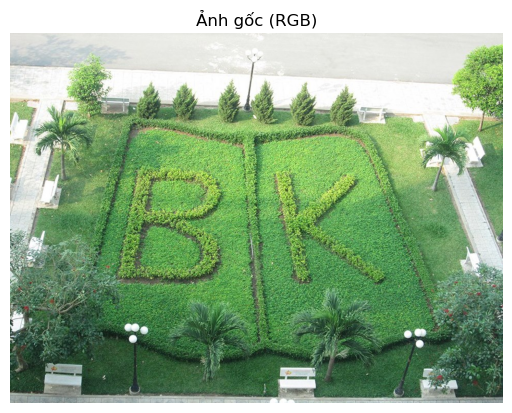

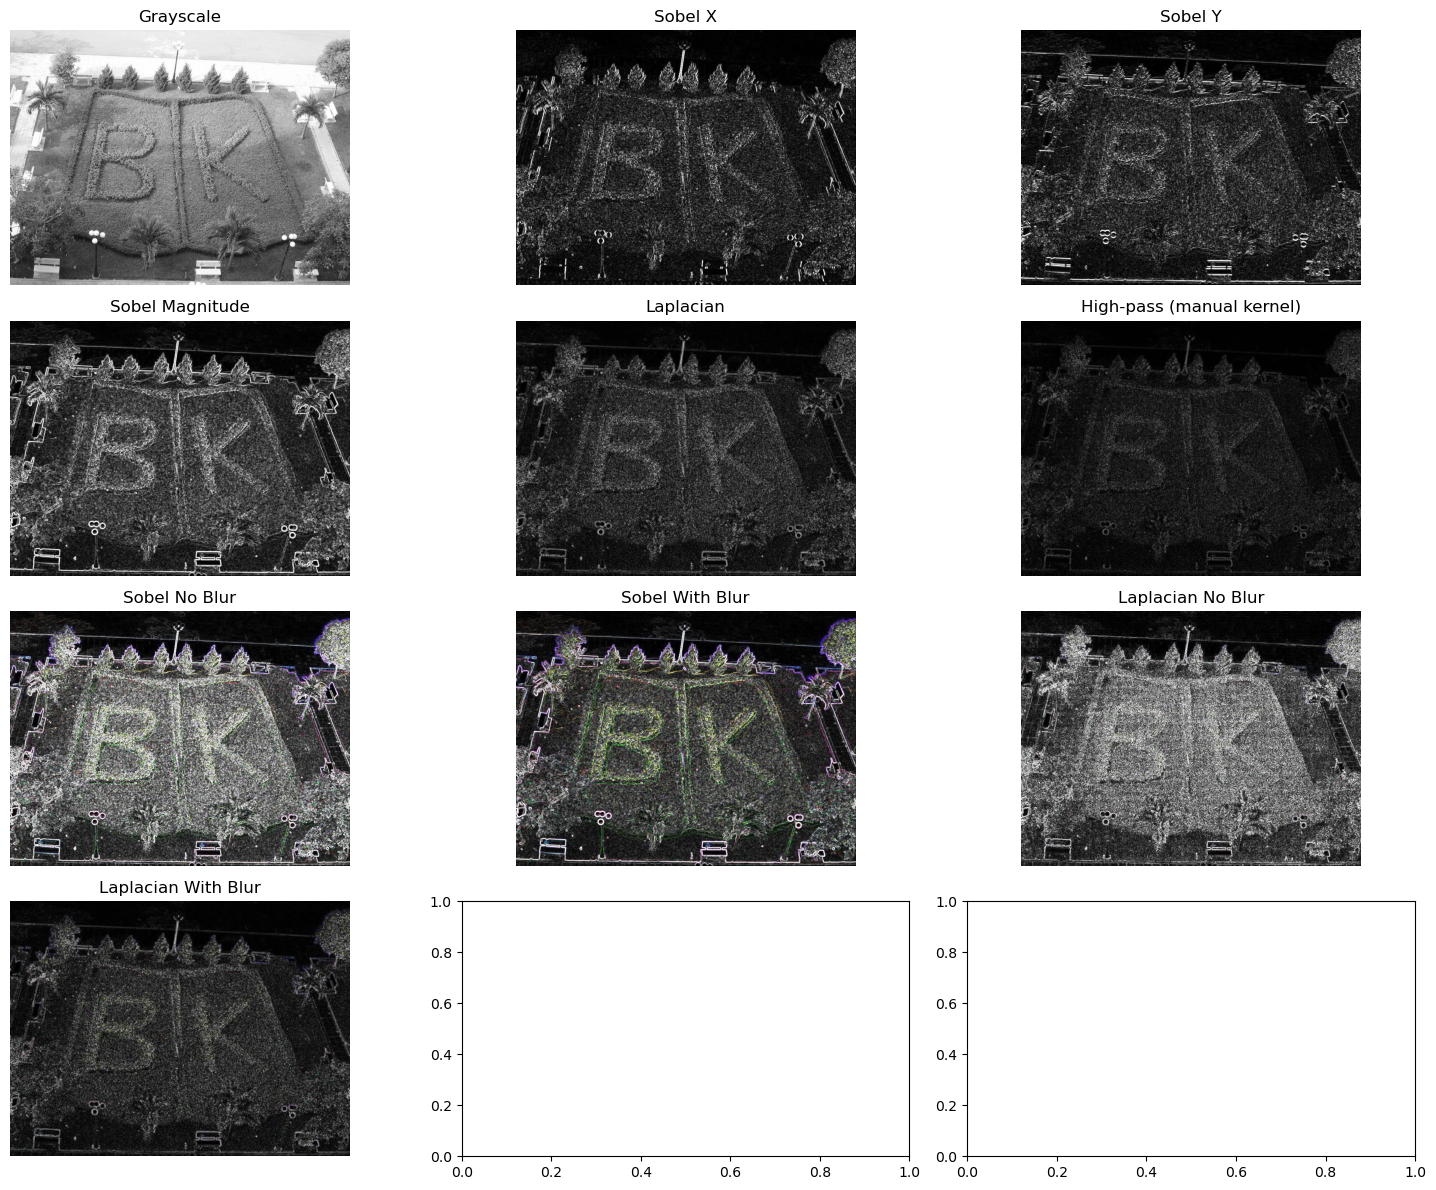

In [77]:
plt.figure()
plt.imshow(img_rgb)
plt.title("Ảnh gốc (RGB)")
plt.axis("off")
plt.show()

fig, axs = plt.subplots(4, 3, figsize=(15, 12))
axs = axs.ravel()

axs[0].imshow(gray, cmap="gray")
axs[0].set_title("Grayscale")
axs[0].axis("off")

axs[1].imshow(sobelx_u8, cmap="gray")
axs[1].set_title("Sobel X")
axs[1].axis("off")

axs[2].imshow(sobely_u8, cmap="gray")
axs[2].set_title("Sobel Y")
axs[2].axis("off")

axs[3].imshow(sobel_mag_u8, cmap="gray")
axs[3].set_title("Sobel Magnitude")
axs[3].axis("off")

axs[4].imshow(lap_u8, cmap="gray")
axs[4].set_title("Laplacian")
axs[4].axis("off")

axs[5].imshow(hp_manual_u8, cmap="gray")
axs[5].set_title("High-pass (manual kernel)")
axs[5].axis("off")

axs[6].imshow(sobel_no_blur, cmap="gray")
axs[6].set_title("Sobel No Blur")
axs[6].axis("off")

axs[7].imshow(sobel_blur, cmap="gray")
axs[7].set_title("Sobel With Blur")
axs[7].axis("off")

axs[8].imshow(lap_no_blur, cmap="gray")
axs[8].set_title("Laplacian No Blur")
axs[8].axis("off")  

axs[9].imshow(lap_blur, cmap="gray")
axs[9].set_title("Laplacian With Blur")
axs[9].axis("off")

plt.tight_layout()
plt.show()